In [211]:
import requests
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import shapely.geometry
import cartopy.crs as ccrs
import cartopy
import cfgrib
import datetime as dt
import glob as glob
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
da_error = xr.open_dataarray('da_error_201601.nc')
da_error_index = xr.open_dataarray('da_error_index_201601.nc')
da_error_rec = xr.open_dataarray('da_error_rec_201601.nc')

In [200]:
def draw_map(da, cmap=None):
    p = da.plot(
        subplot_kws=dict(projection=ccrs.PlateCarree(-80), facecolor="white"),
        transform=ccrs.PlateCarree(),
        cmap=cmap
    )
    ax = p.axes
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES)

    grid = ax.gridlines(draw_labels=['left', 'bottom'], linewidth=1, color='gray', linestyle='--', alpha=0)
    grid.xlocator = plt.MaxNLocator(integer=True, prune='lower', nbins=5)  # 5 bins for x-axis
    grid.ylocator = plt.MaxNLocator(integer=True, prune='lower', nbins=5)  # 5 bins for y-axis')

    plt.tight_layout()
    return p

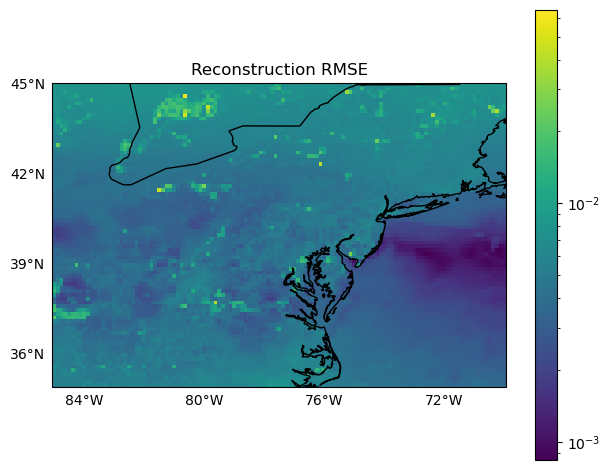

In [224]:
# RMSE
rmse = np.sqrt(((da_error_rec - da_error)**2).mean(axis=0)/31)
p = rmse.plot(
    subplot_kws=dict(projection=ccrs.PlateCarree(-80), facecolor="white"),
    transform=ccrs.PlateCarree(),
    norm=mpl.colors.LogNorm(vmin=rmse.values.min(), vmax=rmse.values.max()),
    vmin=rmse.values.min(),
    vmax=rmse.values.max()
)
ax = p.axes
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
# ax.add_feature(cartopy.feature.STATES)

grid = ax.gridlines(draw_labels=['left', 'bottom'], linewidth=1, color='gray', linestyle='--', alpha=0)
grid.xlocator = plt.MaxNLocator(integer=True, prune='lower', nbins=5)  # 5 bins for x-axis
grid.ylocator = plt.MaxNLocator(integer=True, prune='lower', nbins=5)  # 5 bins for y-axis')

plt.title("Reconstruction RMSE")
plt.tight_layout()
plt.show()

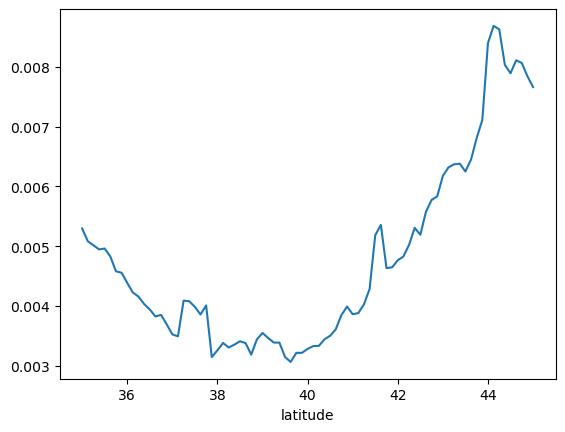

In [222]:
rmse.mean(axis=1).plot()
plt.show()

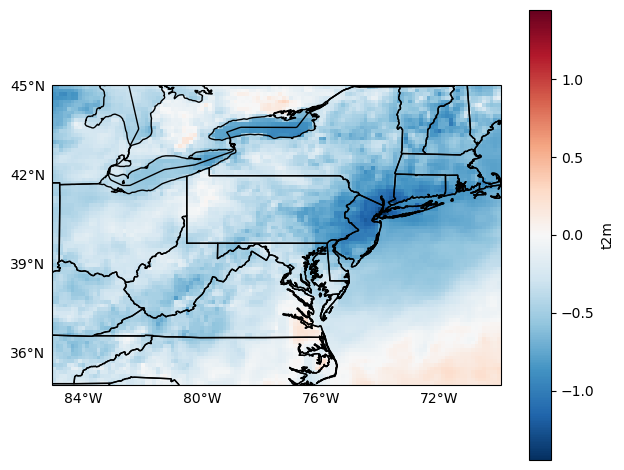

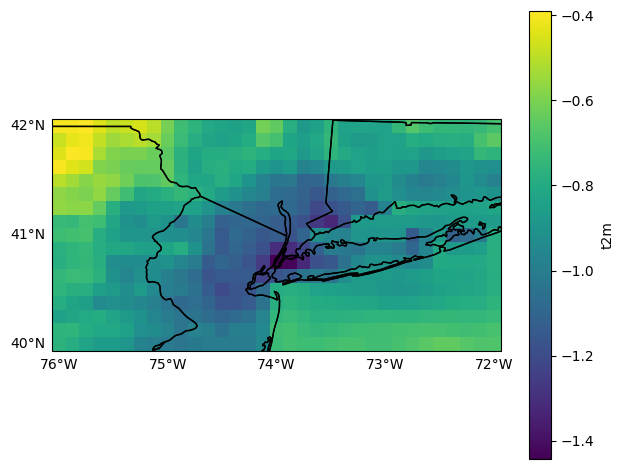

In [174]:
mean_error = da_error.mean(axis=0)
draw_map(mean_error)
plt.show()
draw_map(mean_error.sel(latitude=slice(42,40), longitude=slice(-76,-72)))
plt.show()

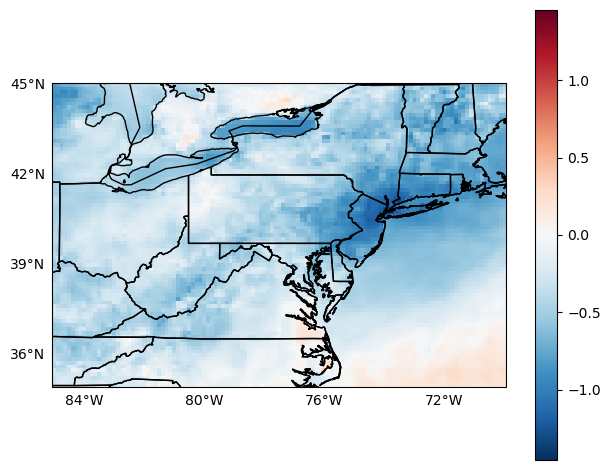

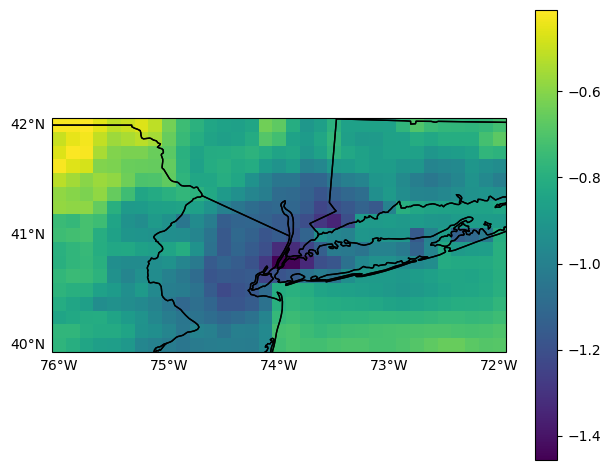

In [177]:
mean_error_rec = da_error_rec.mean(axis=0)
draw_map(mean_error_rec)
plt.show()
draw_map(mean_error_rec.sel(latitude=slice(42,40), longitude=slice(-76,-72)))
plt.show()

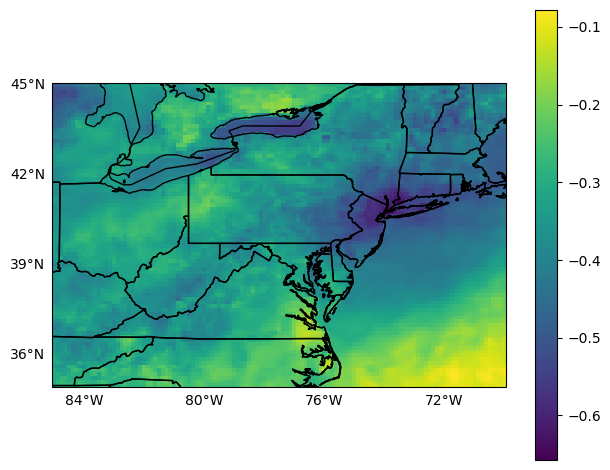

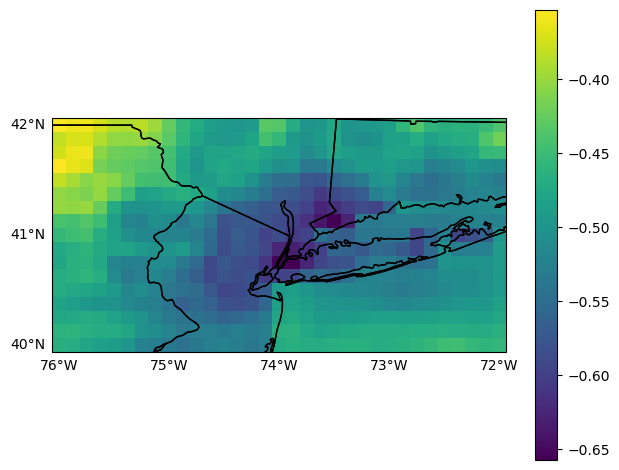

In [178]:
mean_index = da_error_index.mean(axis=0)
draw_map(mean_index)
plt.show()
draw_map(mean_index.sel(latitude=slice(42,40), longitude=slice(-76,-72)))
plt.show()

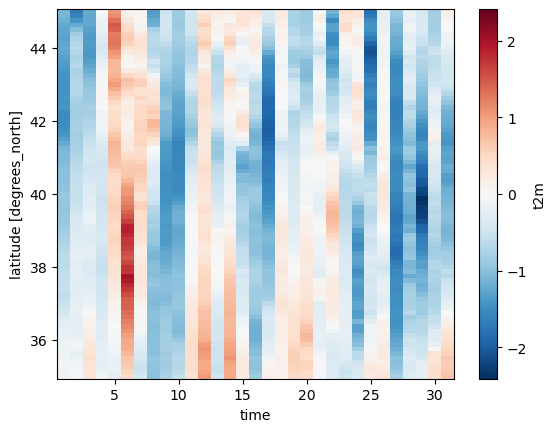

In [179]:
da_error.mean(axis=2).T.plot()
plt.show()

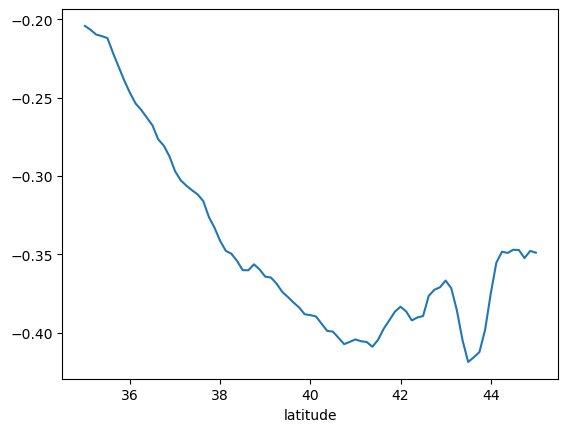

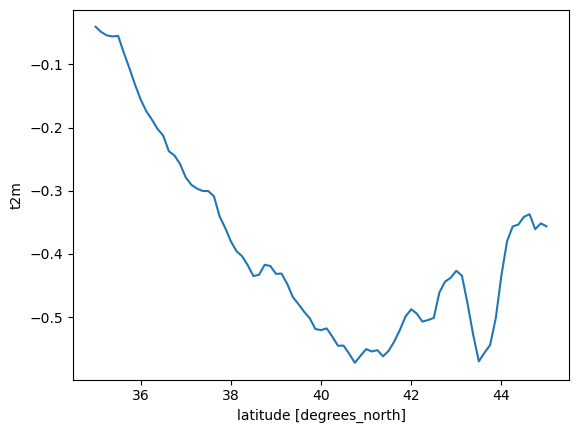

In [181]:
da_error_index.mean(axis=2).mean(axis=0).plot()
plt.show()
da_error.mean(axis=2).mean(axis=0).plot()
plt.show()

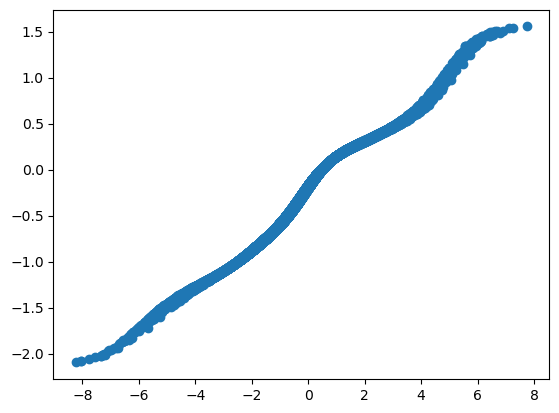

In [194]:
plt.scatter(da_error.values.reshape(31*81*121,), da_error_index.values.reshape(31*81*121,))
plt.show()

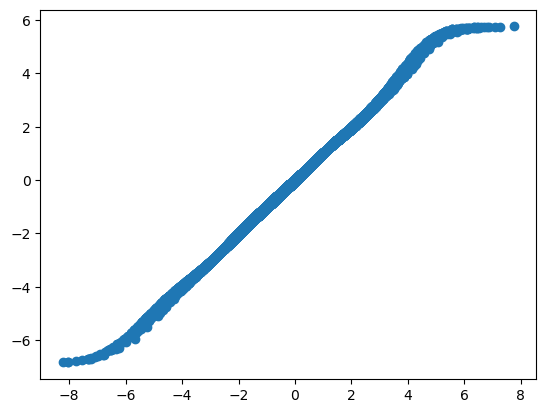

In [193]:
plt.scatter(da_error.values.reshape(31*81*121,), da_error_rec.values.reshape(31*81*121,))
plt.show()

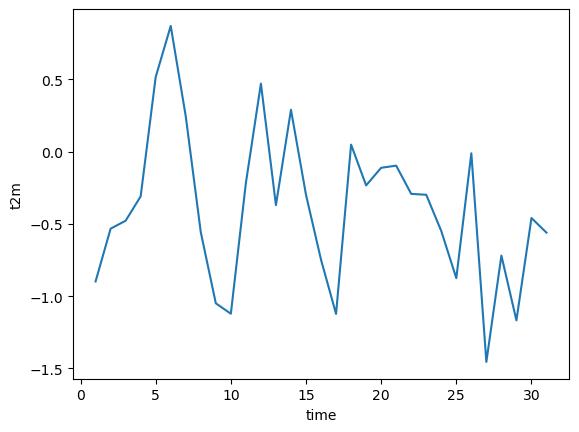

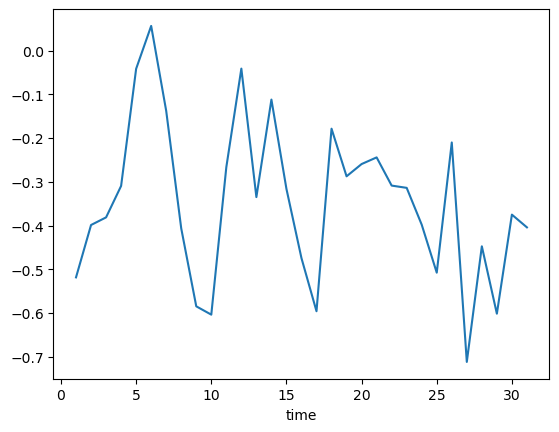

In [191]:
da_error.mean(axis=1).mean(axis=1).plot()
plt.show()
da_error_index.mean(axis=1).mean(axis=1).plot()
plt.show()

In [225]:
API_KEY = '505d7c44c1572da9b661bb9b5b3e4df82c08ae11'

In [226]:
url = f'https://api.census.gov/data/2020/dec/pl2020?get=GEO_ID&for=block%20group:*&in=state:06&key={API_KEY}'

In [227]:
requests.get(url)

<Response [404]>